In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [4]:
titanic=sns.load_dataset("titanic")

In [5]:
titanic.head()
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [6]:
features=["pclass", "sex", "age", "fare", "embarked"]
target=["survived"]

In [7]:
#handle missing value
from sklearn.impute import SimpleImputer

imp_median=SimpleImputer(strategy="median")
titanic[["age"]]= imp_median.fit_transform(titanic[["age"]])

imp_freq=SimpleImputer(strategy="most_frequent")
titanic[["embarked"]]=imp_freq.fit_transform(titanic[["embarked"]])

In [8]:
#encoding
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()

titanic["sex"]= le.fit_transform(titanic["sex"])
titanic["embarked"]= le.fit_transform(titanic["embarked"])

In [27]:
#train test split
x=titanic[features]
y=titanic["survived"]


In [28]:
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=42)

In [11]:
x_test

,pclass,sex,age,fare,embarked
709,3,1,28.0,15.2458,0
439,2,1,31.0,10.5000,2
840,3,1,20.0,7.9250,2
720,2,0,6.0,33.0000,2
39,3,0,14.0,11.2417,0
...,...,...,...,...,...
433,3,1,17.0,7.1250,2
773,3,1,28.0,7.2250,0
25,3,0,38.0,31.3875,2
84,2,0,17.0,10.5000,2


In [12]:
#Decision tree model (no pruning)
from sklearn.tree import DecisionTreeClassifier

model= DecisionTreeClassifier()
model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [13]:
from sklearn.metrics import accuracy_score

y_pred= model.predict(x_test)

print("accuracy_score:", accuracy_score(y_test, y_pred))

accuracy_score: 0.7597765363128491


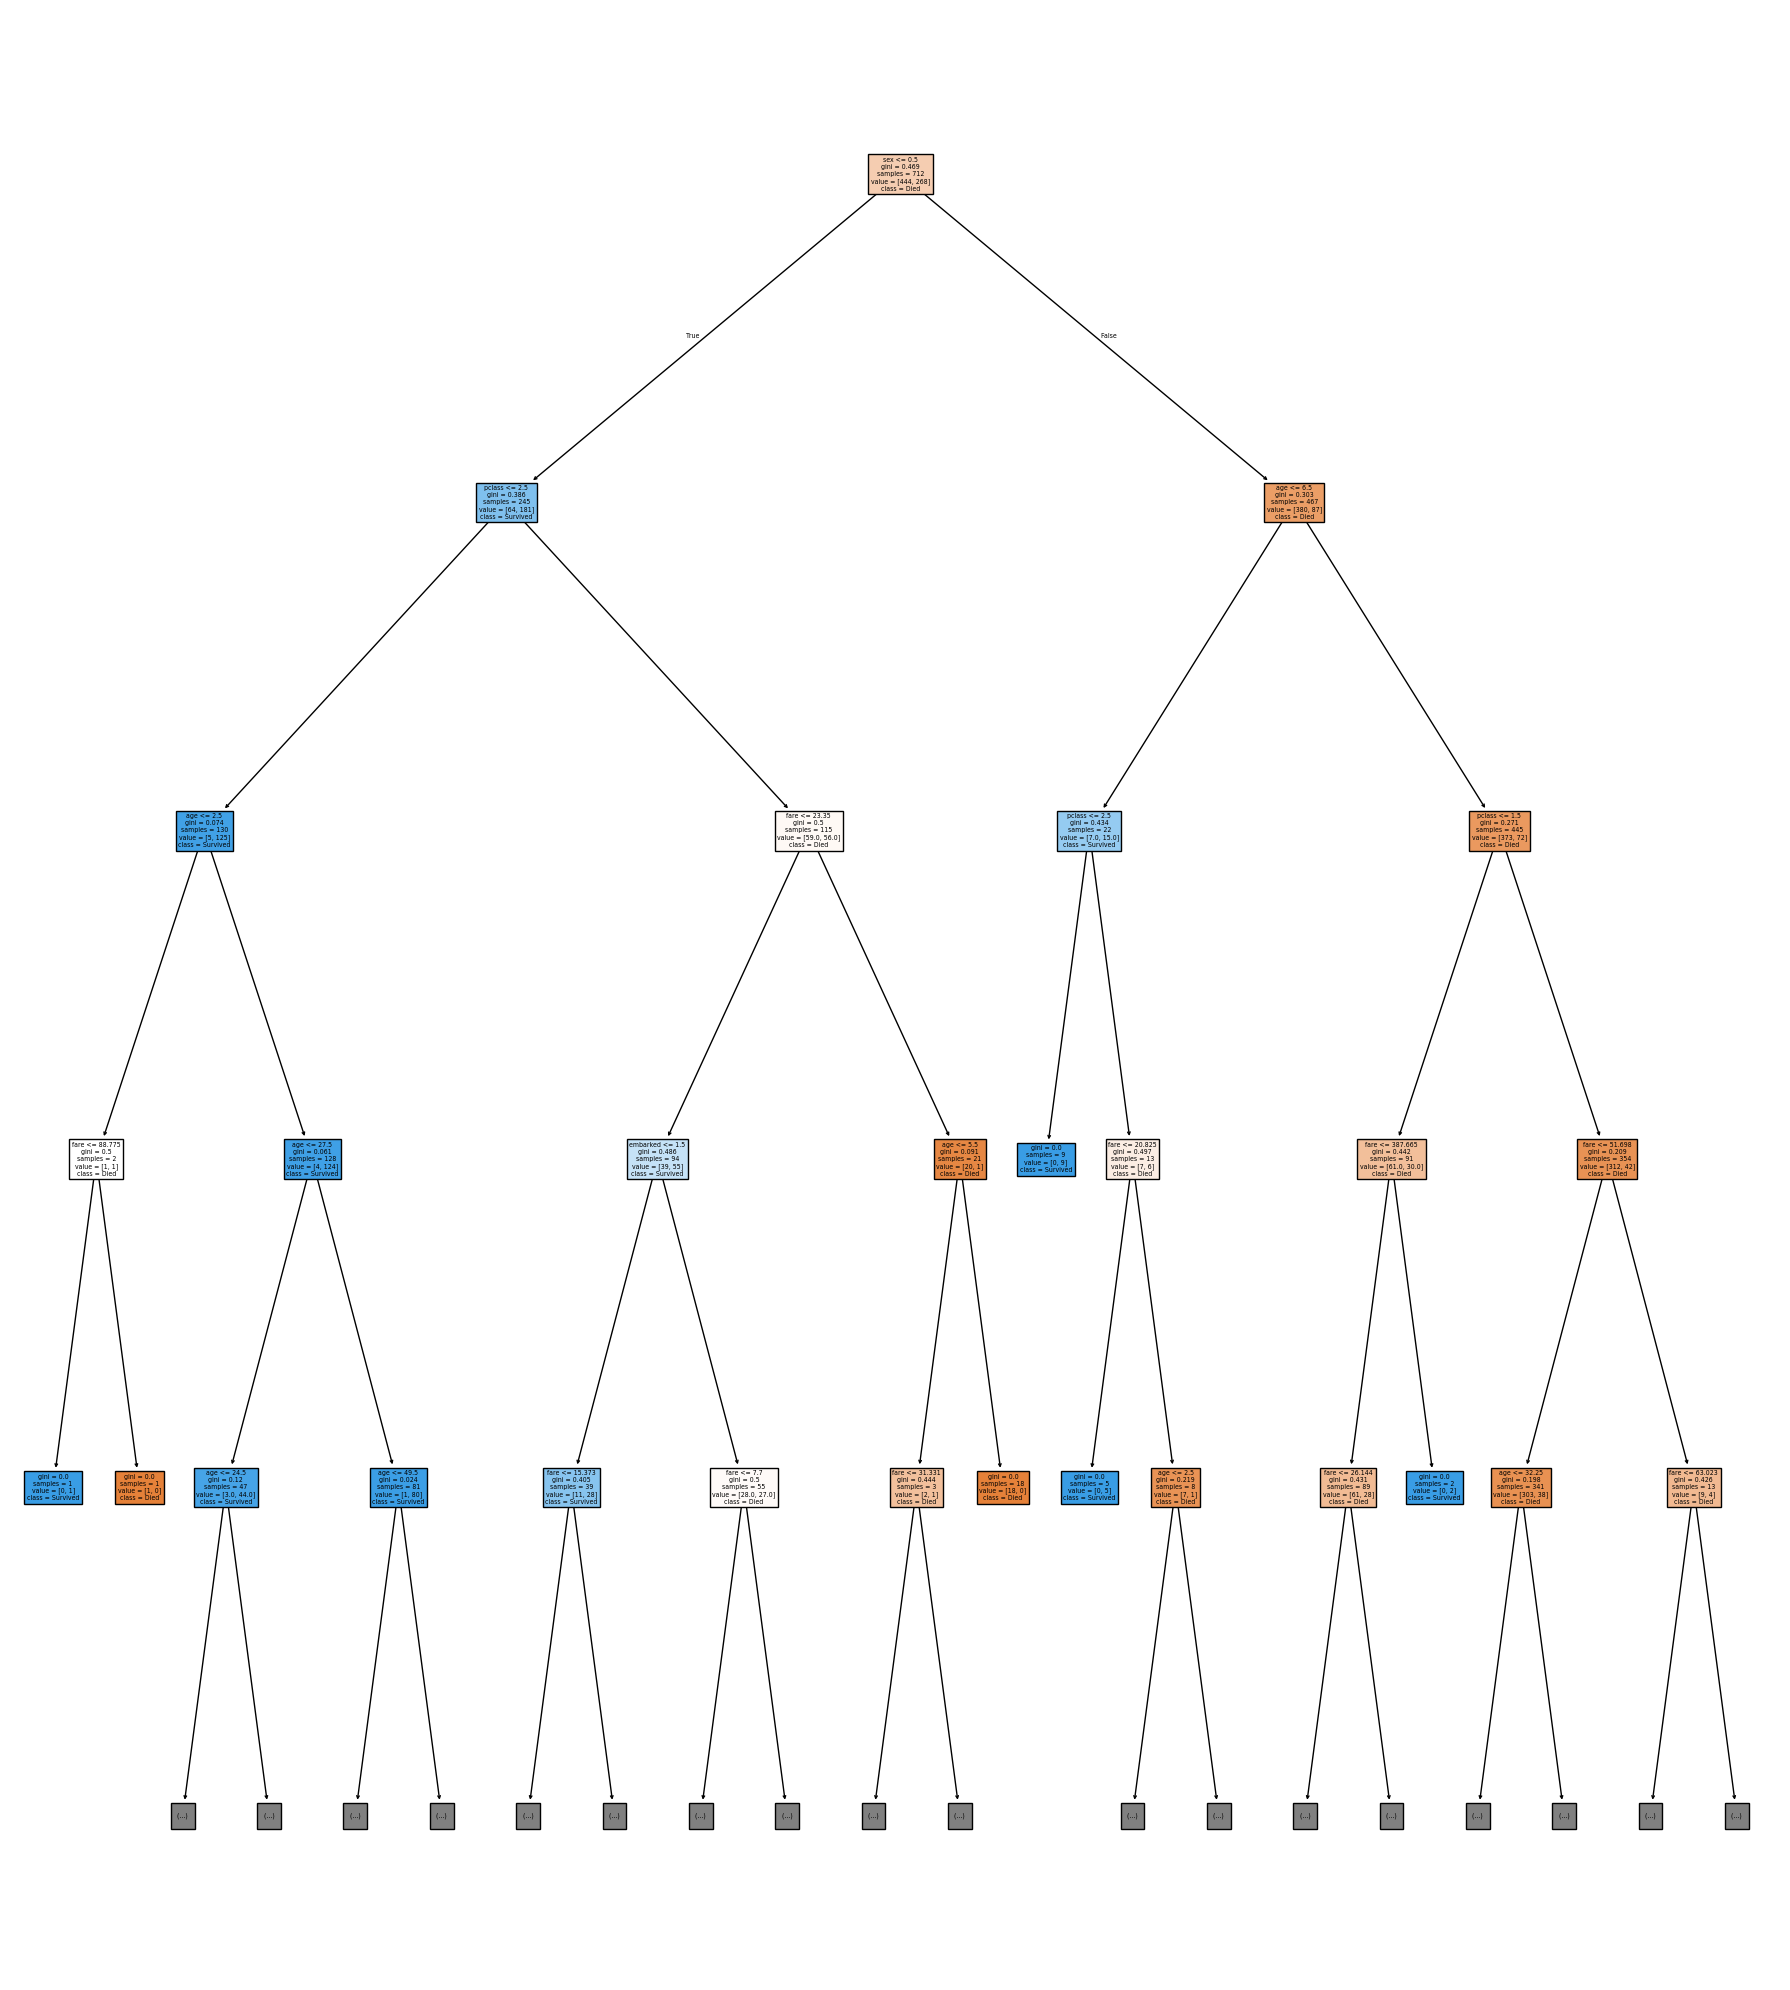

In [14]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,20))
plot_tree(
    model,
    feature_names=x.columns,
    class_names=["Died","Survived"],
    filled=True,
    max_depth=4
)

plt.tight_layout()
plt.show()

Decision Tree with Pre-Pruning

In [16]:
max_depth= [2, 3, 4, 5, 6, 7, 8, 9, 10]

for depth in max_depth:
    model= DecisionTreeClassifier(max_depth=depth)
    model.fit(x_train, y_train)

    acc=model.score(x_test, y_test)
    print(f"for depth: {depth}, accuracy: {acc}")

for depth: 2, accuracy: 0.7653631284916201
for depth: 3, accuracy: 0.7988826815642458
for depth: 4, accuracy: 0.7988826815642458
for depth: 5, accuracy: 0.7988826815642458
for depth: 6, accuracy: 0.7988826815642458
for depth: 7, accuracy: 0.7988826815642458
for depth: 8, accuracy: 0.7988826815642458
for depth: 9, accuracy: 0.7821229050279329
for depth: 10, accuracy: 0.7932960893854749


In [17]:
model= DecisionTreeClassifier(max_depth=4, min_samples_split=10)
model.fit(x_train, y_train)

acc=model.score(x_test, y_test)
print(f"for depth: {depth}, accuracy: {acc}")

for depth: 10, accuracy: 0.7988826815642458


Decision Tree with post-pruning

In [18]:
full_tree= DecisionTreeClassifier(random_state=42)
full_tree.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [19]:
path= full_tree.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas= path.ccp_alphas

print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [20]:
#train our model for all alphas

trees=[]

for alpha in ccp_alphas:
    model= DecisionTreeClassifier(random_state=42, ccp_alpha= alpha)
    model.fit(x_train, y_train)

    trees.append((model,alpha))

In [21]:
best_acc=0
best_alpha=0

for model, alpha in trees:
    curr_acc = model.score(x_test, y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha

In [22]:
best_acc

0.8379888268156425

In [23]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha)
best_model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


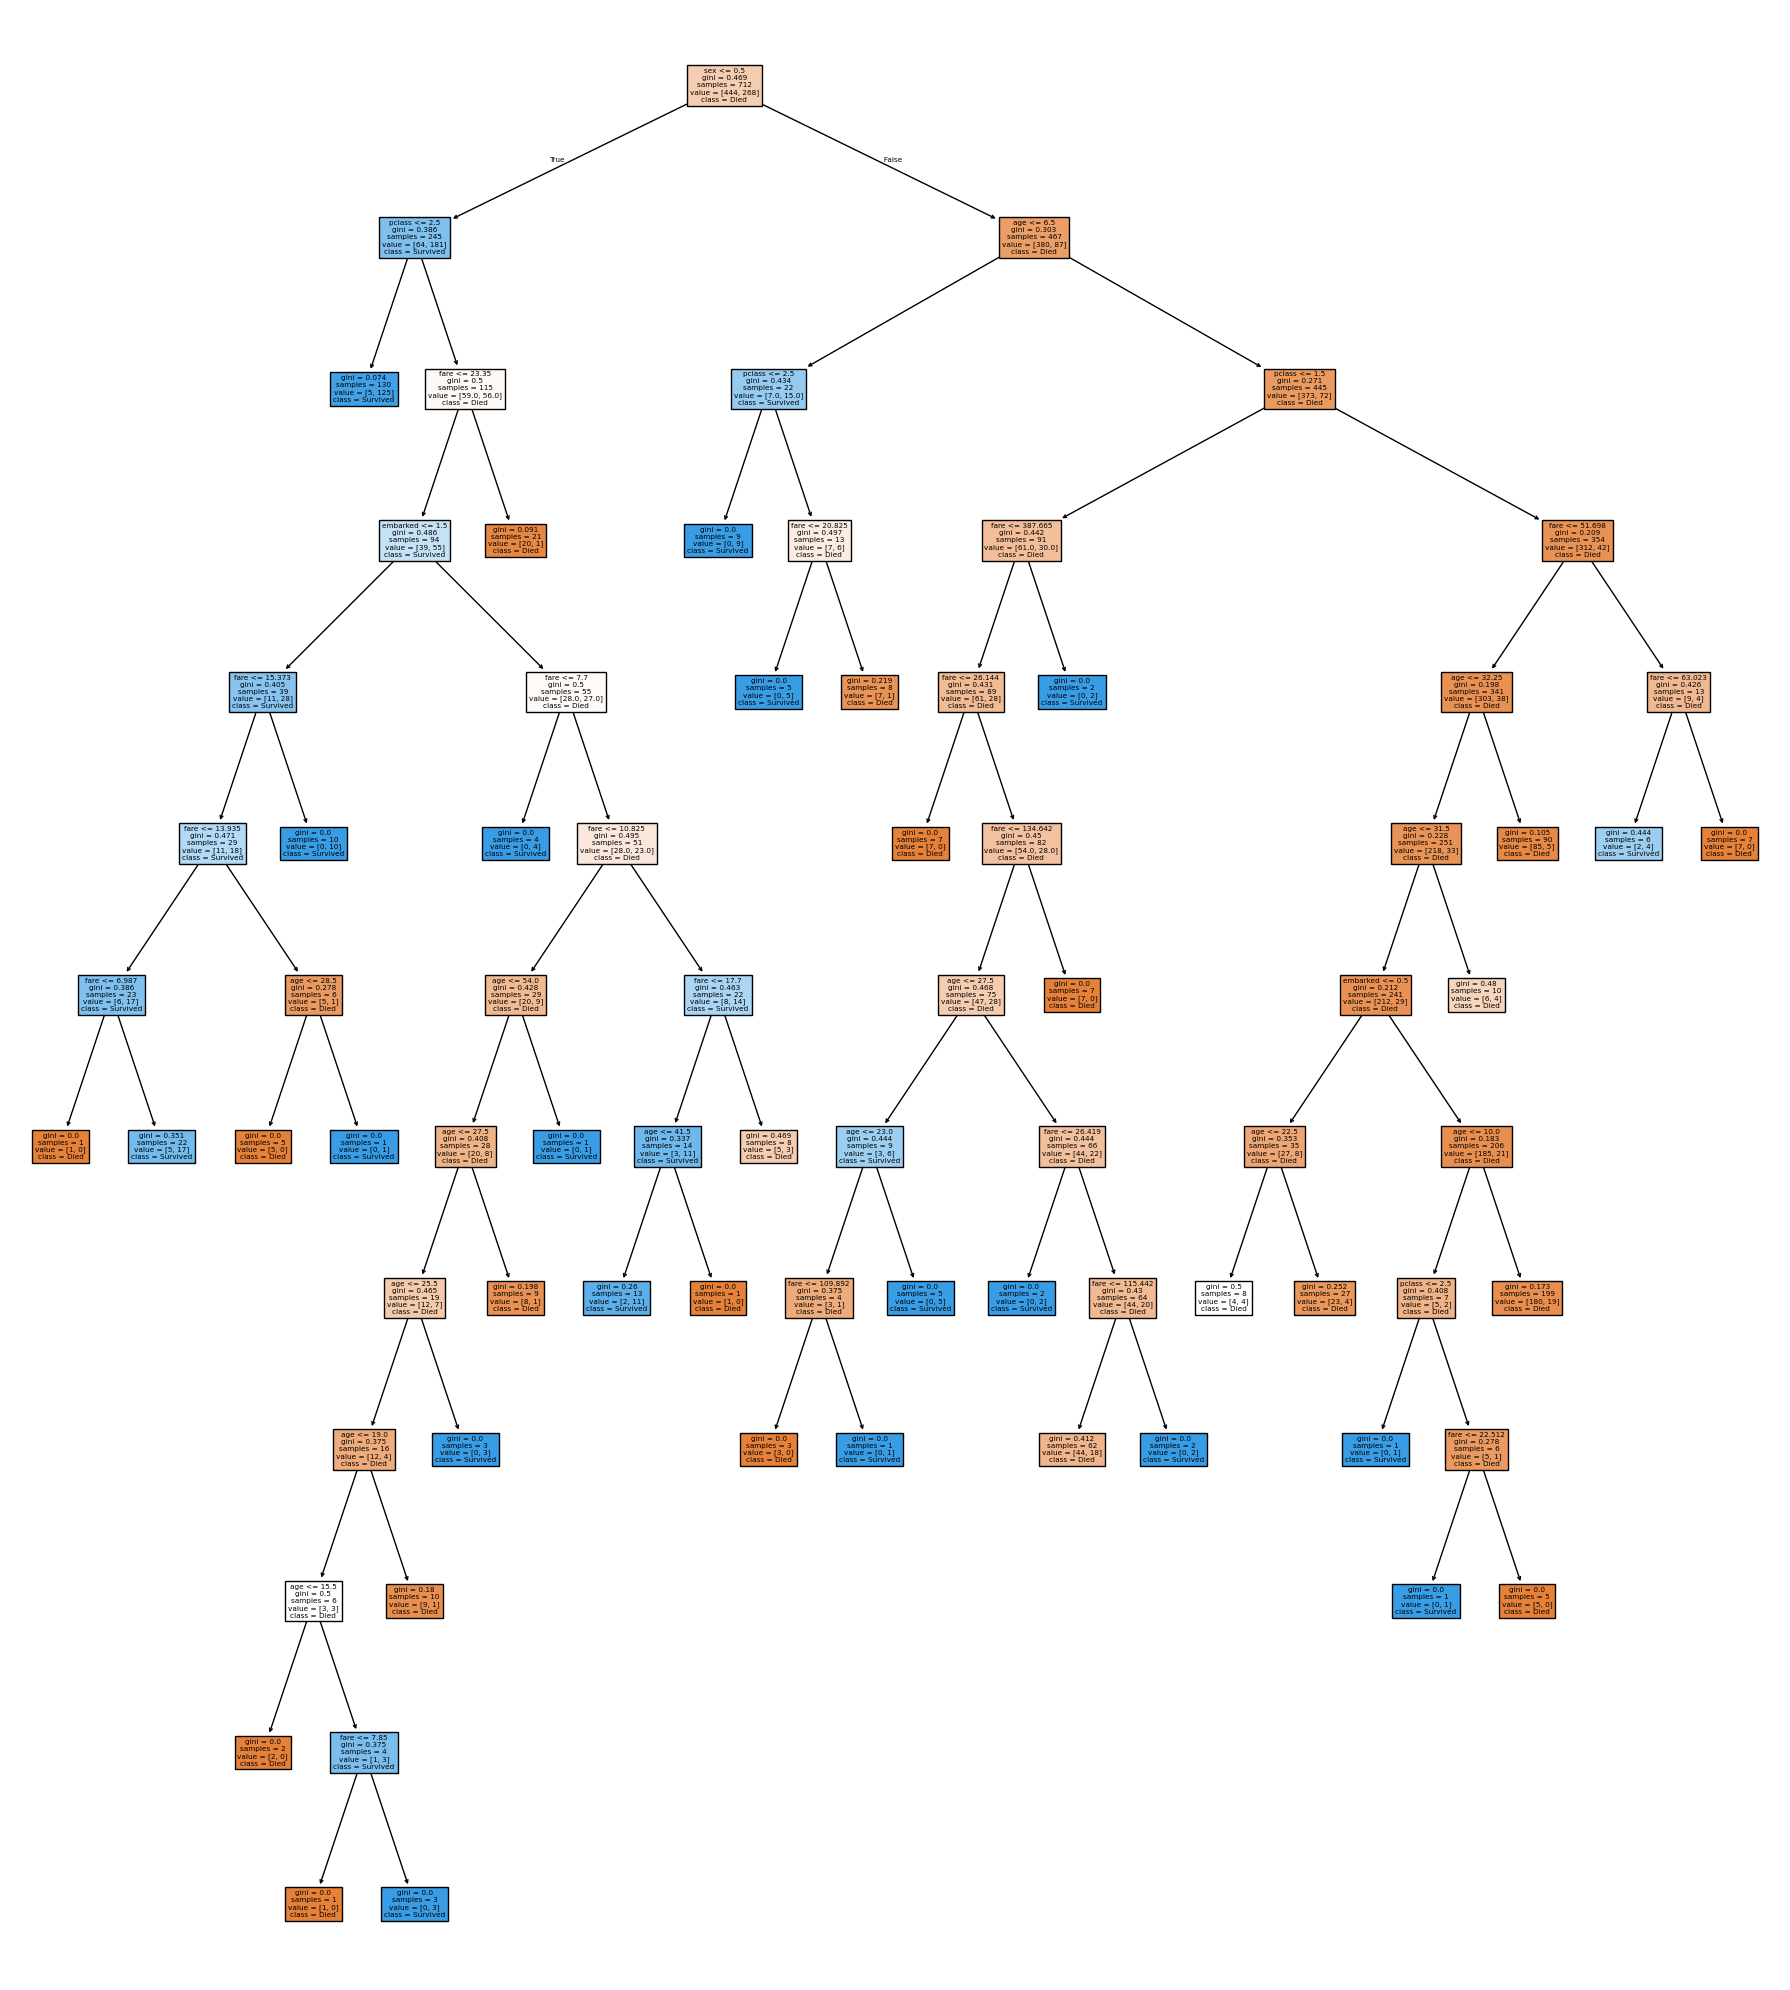

In [24]:
plt.figure(figsize=(18,20))
plot_tree(
    best_model,
    feature_names=x.columns,
    class_names=["Died","Survived"],
    filled=True,
)

plt.tight_layout()
plt.show()

In [25]:
print(best_model.score(x_test, y_test))

0.8435754189944135


#Random Forest

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=301,
    oob_score=True
)

rf.fit(x_train, y_train)

y_pred= rf.predict(x_test)

print("OOB score: ", rf.oob_score_ * 100, "%")
print("testing accuracy: ", accuracy_score(y_test, y_pred) * 100, "%")

OOB score:  80.33707865168539 %
testing accuracy:  79.88826815642457 %
